# Baseline: Jev vs Claude Opus vs Claude Sonnet on one cluster

Two marker lists, same question set, three models. Only two things are compared: **how long each call takes** and **what each model answers**.

| Case | `marker_genes` | `tissue` |
|---|---|---|
| `base` | CD3D, CD3E, TRAC, IL7R, LTB | blood |
| `base + LST1` | the same five plus **LST1** (a monocyte gene) appended last | blood |

The state and questions are the default [JevCellType](https://github.com/yw-Hua/JevCellType) payload, stored in `inputs/`:
- `broad_type`: a choice among 8 options;
- `cell_type`: a choice among 26 options;
- `identity_coherence`: a 0–4 score.

**How each model is asked**
- **Jev** receives the payload exactly as written in `inputs/`.
- **Claude** receives the same state and the same questions as JSON. Its answer is constrained by a JSON schema: each choice must be one of the option keys, and coherence must be a level from 0 to 4.

**Notes on the comparison**
- **Time** is wall-clock seconds per call, network included. Calls run one at a time, never in parallel.
- **Retries**: a call is retried only on rate limits, overload, or network errors. Only the successful attempt is timed.
- **Coherence scales differ**: Jev returns the probability-weighted level (e.g. 3.67); Claude returns one whole level.
- **Model pinning**: Claude runs without server-side refusal fallbacks, so every answer comes from the model named in its row.
- **Cost**: these calls are real and billed (pennies in total). Jev's per-call cost is far below Claude's.

## Definitions

| Term | Meaning |
|---|---|
| **Marker genes** | Genes most specific to a cluster, ranked by differential expression of the cluster against all other cells. Here they are a fixed, hand-written list, not computed from data. |
| **Tissue** | Free-text context sent with the markers (`blood`). |
| **LST1** | A gene expressed mainly in monocytes, not in T cells. Adding it to a T-cell list introduces conflicting evidence. |
| **Broad type** (`broad_type`) | A choice question: which of 7 broad categories the markers indicate (immune, endothelial, epithelial, stromal, muscle, neural, erythroid), or "Unknown / other". |
| **Cell type** (`cell_type`) | A choice question: which of 25 specific cell types the markers indicate, or "Unknown / other". |
| **Coherence score** (`identity_coherence`) | The answer to "How strongly do the marker genes support one clear, coherent cell identity?" on a 0–4 scale (rubric below). It is the model's judgement of the marker list, **not** a measured accuracy or cluster purity. |
| **`p_cell_type`** | Jev's probability for the cell type it chose. Claude does not return one. |
| **`median_s`** | Median seconds per call (wall clock, network included) across the repeats. |
| **95% CI** (`*_lo`, `*_hi`, error bars) | The range in which the median time, or the mean coherence, of repeated identical calls is expected to lie, estimated by bootstrap resampling of the 10 repeats. It measures run-to-run variation on the same input only, **not** how accurate a model is. |
| **`x_vs_jev`** | A model's median time divided by Jev's median time for the same case. |
| **(10/10)** | How many of the repeats gave that answer. |

**Coherence rubric.** All three models see the same levels. These are shortened; the full text is in `inputs/questions.json`.

| Level | Meaning |
|---|---|
| 0 | No reliable single identity: the markers are insufficient, nonspecific, or strongly conflicting |
| 1 | Weak: substantial conflicting or mixed evidence |
| 2 | Ambiguous: one or more plausible identities, with meaningful conflicting evidence |
| 3 | Mostly coherent: one identity clearly favoured, with only minor conflicting or nonspecific evidence |
| 4 | Highly coherent: the markers strongly and consistently support one identity |

**Where the score comes from.** The coherence question and its rubric are part of the input question set (`inputs/questions.json`), which is the default question set of the JevCellType package. It is not a standard single-cell metric.

**How each model produces it**
- **Jev** returns a probability for each level. The score is the probability-weighted average level, so it is a decimal such as 3.66. The worked example below shows the calculation.
- **Claude** is asked to pick one level, so its score is a whole number.

## Setup

Run this notebook from `Tests/Baseline/`.

**Keys** are never stored in this repo. Each key is read from an environment variable first, then from a one-line file in the repo-level `keys/` folder (which is git-ignored):
- **Jev**: `TYPESAFE_API_KEY` (TypeSafe API) **or** `OPENROUTER_API_KEY` (OpenRouter Decisions endpoint).
- **Claude**: `ANTHROPIC_API_KEY`, or a profile from `ant auth login`. The Anthropic SDK resolves this on its own.

In [1]:
import json
import os
import time
from collections import Counter
from pathlib import Path

import anthropic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

HERE = Path.cwd()                      # run from Tests/Baseline/
INPUTS, OUTPUTS = HERE / "inputs", HERE / "outputs"
KEYS = HERE.parents[1] / "keys"        # <repo>/keys, git-ignored

N_REPEATS = 10                         # identical calls per model per case
MAX_ATTEMPTS = 3                       # retries only for rate limits, overload, network

CLAUDE_MODELS = {"Claude Opus 5.5": "claude-opus-5-5", "Claude Sonnet 5.5": "claude-sonnet-5-5"}
CLAUDE_EFFORT = "medium"               # same for both; defaults differ (Opus 5.5: medium, Sonnet 5.5: high)

JEV_ROUTES = {
    "typesafe":   {"endpoint": "https://api.typesafe.ai/v1/systemone",      "model": "jev-1.13.0",        "key": "TYPESAFE_API_KEY"},
    "openrouter": {"endpoint": "https://openrouter.ai/api/alpha/decisions", "model": "typesafe/jev-1.13", "key": "OPENROUTER_API_KEY"},
}
JEV_ROUTE = None                       # None: use the first route whose key is found

## Inputs: the two cases

In [2]:
state = json.loads((INPUTS / "state.json").read_text())
questions = json.loads((INPUTS / "questions.json").read_text())

cases = {
    "base": state,
    "base + LST1": {**state, "marker_genes": state["marker_genes"] + ["LST1"]},
}
for name, s in cases.items():
    print(f"{name:12s} {s}")
for q, spec in questions.items():
    print(f"{q:20s} {spec['type']:6s} {len(spec['criteria'])} options")

base         {'marker_genes': ['CD3D', 'CD3E', 'TRAC', 'IL7R', 'LTB'], 'tissue': 'blood'}
base + LST1  {'marker_genes': ['CD3D', 'CD3E', 'TRAC', 'IL7R', 'LTB', 'LST1'], 'tissue': 'blood'}
broad_type           choice 8 options
cell_type            choice 26 options
identity_coherence   score  5 options


## Callers

Each caller returns `(seconds, answer, raw_response)`. `timed()` retries transient failures and keeps the timing of the successful attempt only.

In [3]:
class Transient(Exception):
    """A failure worth retrying: rate limit, overload, or network."""


def read_key(name):
    """Environment variable first, then a one-line file keys/<name>."""
    value = os.environ.get(name, "").strip()
    if not value and (KEYS / name).is_file():
        value = (KEYS / name).read_text(encoding="utf-8").strip()
    return value or None


def timed(call):
    for attempt in range(1, MAX_ATTEMPTS + 1):
        try:
            seconds, answer, raw = call()
            return {"status": "ok", "attempts": attempt, "seconds": round(seconds, 3), **answer}, raw
        except Transient as exc:
            last_error = str(exc)
            time.sleep(2 ** attempt)
    return {"status": "error", "attempts": MAX_ATTEMPTS, "error": last_error}, None

In [4]:
def find_jev_route():
    for name in [JEV_ROUTE] if JEV_ROUTE else list(JEV_ROUTES):
        key = read_key(JEV_ROUTES[name]["key"])
        if key:
            return name, key
    raise RuntimeError("No Jev key found: set TYPESAFE_API_KEY or OPENROUTER_API_KEY, "
                       "or save the key alone in keys/TYPESAFE_API_KEY or keys/OPENROUTER_API_KEY.")


def ask_jev(state, session, route, key):
    cfg = JEV_ROUTES[route]
    payload = {"model": cfg["model"], "state": state, "questions": questions}
    t0 = time.perf_counter()
    try:
        r = session.post(cfg["endpoint"], json=payload, timeout=60,
                         headers={"Authorization": f"Bearer {key}"})
    except (requests.ConnectionError, requests.Timeout) as exc:
        raise Transient(f"network: {type(exc).__name__}") from exc
    seconds = time.perf_counter() - t0
    if r.status_code in (408, 429) or r.status_code >= 500:
        raise Transient(f"HTTP {r.status_code}")
    r.raise_for_status()                # 401/403/422 etc. stop the run: fix the key or payload
    data = r.json()
    a = data["answers"]
    return seconds, {
        "broad_type": a["broad_type"]["choice"],
        "cell_type": a["cell_type"]["choice"],
        "p_cell_type": a["cell_type"]["probabilities"][a["cell_type"]["choice"]],
        "coherence": a["identity_coherence"]["score"],
        "model_returned": data.get("model"),
    }, data

In [5]:
# keys/ANTHROPIC_API_KEY if present; otherwise the SDK's own lookup (env var or `ant auth login`)
client = anthropic.Anthropic(api_key=read_key("ANTHROPIC_API_KEY"), max_retries=0, timeout=300)  # retries handled by timed()
print("Claude endpoint:", client.base_url)


def answer_schema(questions):
    """Choice -> one of its option keys; score -> a level index."""
    props = {
        q: {"type": "string", "enum": list(spec["criteria"])} if spec["type"] == "choice"
        else {"type": "integer", "enum": list(range(len(spec["criteria"])))}
        for q, spec in questions.items()
    }
    return {"type": "object", "properties": props, "required": list(props), "additionalProperties": False}


SCHEMA = answer_schema(questions)
SYSTEM = (
    "You annotate clusters from single-cell RNA-seq data. You receive a cluster's state "
    "(marker genes ranked by differential expression against all other clusters, and the tissue) "
    "and a set of questions. Answer every question. For a choice question, answer with one of its "
    "option keys exactly. For a score question, answer with the index of the level that fits best, "
    "where 0 is the first level listed."
)


def ask_claude(model, state):
    prompt = (f"<state>\n{json.dumps(state, indent=2)}\n</state>\n\n"
              f"<questions>\n{json.dumps(questions, indent=2)}\n</questions>")
    t0 = time.perf_counter()
    try:
        response = client.messages.create(
            model=model,
            max_tokens=16000,
            system=SYSTEM,
            output_config={"effort": CLAUDE_EFFORT,
                           "format": {"type": "json_schema", "schema": SCHEMA}},
            messages=[{"role": "user", "content": prompt}],
        )
    except (anthropic.RateLimitError, anthropic.OverloadedError, anthropic.InternalServerError,
            anthropic.ServiceUnavailableError, anthropic.APIConnectionError) as exc:
        raise Transient(type(exc).__name__) from exc
    seconds = time.perf_counter() - t0
    answer = {"model_returned": response.model, "stop_reason": response.stop_reason}
    if response.stop_reason == "end_turn":
        a = json.loads(next(b.text for b in response.content if b.type == "text"))
        answer |= {"broad_type": a["broad_type"], "cell_type": a["cell_type"],
                   "coherence": a["identity_coherence"]}
    return seconds, answer, response.to_dict()

Claude endpoint: https://api.anthropic.com


## Run

Each repeat runs every case through every model, so the run makes 3 models × 2 cases × `N_REPEATS` calls. The first call to each service includes connection setup, which is why the summary reports the median.

In [6]:
route, jev_key = find_jev_route()
print(f"Jev route: {route} -> {JEV_ROUTES[route]['model']}")

records, raw = [], []
with requests.Session() as session:
    contenders = {"Jev": lambda s: ask_jev(s, session, route, jev_key)}
    contenders |= {name: (lambda s, m=model: ask_claude(m, s)) for name, model in CLAUDE_MODELS.items()}
    for repeat in range(1, N_REPEATS + 1):
        for case, s in cases.items():
            for name, ask in contenders.items():
                row, response = timed(lambda: ask(s))
                records.append({"case": case, "model": name, "repeat": repeat, **row})
                raw.append({"case": case, "model": name, "repeat": repeat, "response": response})
                print(f"rep {repeat}  {case:12s} {name:18s} {row.get('seconds', '-'):>7}s  "
                      f"{row.get('cell_type') or row.get('error') or row.get('stop_reason')}")

Jev route: typesafe -> jev-1.13.0


rep 1  base         Jev                  0.249s  T cell


rep 1  base         Claude Opus 5.5      1.494s  T cell


rep 1  base         Claude Sonnet 5.5    1.677s  T cell
rep 1  base + LST1  Jev                  0.168s  T cell


rep 1  base + LST1  Claude Opus 5.5      1.884s  T cell


...

rep 9  base + LST1  Claude Sonnet 5.5    1.772s  T cell
rep 10  base         Jev                  0.127s  T cell


rep 10  base         Claude Opus 5.5      1.923s  T cell


rep 10  base         Claude Sonnet 5.5    1.389s  T cell
rep 10  base + LST1  Jev                  0.132s  T cell


rep 10  base + LST1  Claude Opus 5.5      1.484s  T cell


rep 10  base + LST1  Claude Sonnet 5.5    1.612s  T cell


## Results: every call

In [7]:
calls = pd.DataFrame(records)
cols = ["case", "model", "repeat", "status", "seconds", "broad_type", "cell_type", "p_cell_type", "coherence"]
calls[[c for c in cols if c in calls]]

,case,model,repeat,status,seconds,broad_type,cell_type,p_cell_type,coherence
0,base,Jev,1,ok,0.249,Immune cell,T cell,1.0,3.65
1,base,Claude Opus 5.5,1,ok,1.494,Immune cell,T cell,NaN,4.00
2,base,Claude Sonnet 5.5,1,ok,1.677,Immune cell,T cell,NaN,4.00
3,base + LST1,Jev,1,ok,0.168,Immune cell,T cell,1.0,3.26
4,base + LST1,Claude Opus 5.5,1,ok,1.884,Immune cell,T cell,NaN,3.00
5,base + LST1,Claude Sonnet 5.5,1,ok,1.774,Immune cell,T cell,NaN,3.00
6,base,Jev,2,ok,0.134,Immune cell,T cell,1.0,3.69
7,base,Claude Opus 5.5,2,ok,1.281,Immune cell,T cell,NaN,4.00
8,base,Claude Sonnet 5.5,2,ok,1.366,Immune cell,T cell,NaN,4.00
9,base + LST1,Jev,2,ok,0.153,Immune cell,T cell,1.0,3.27


## Summary: time and answers per case and model

- `cell_type` and `broad_type` show the most common answer and how many repeats gave it.
- `x_vs_jev` is the model's median time divided by Jev's median time for the same case.
- `*_lo` / `*_hi` are the 95% bootstrap confidence interval: 10,000 resamples of the repeats, with a fixed seed.

In [8]:
def modal(values):
    values = [v for v in values if v is not None]
    if not values:
        return None
    label, n = Counter(values).most_common(1)[0]
    return f"{label} ({n}/{len(values)})"


rng = np.random.default_rng(0)


def boot_ci(values, stat, n_boot=10_000):
    """95% percentile bootstrap interval of stat (np.median or np.mean)."""
    v = np.asarray(values, dtype=float)
    lo, hi = np.percentile(stat(rng.choice(v, size=(n_boot, len(v))), axis=1), [2.5, 97.5])
    return lo, hi


ok = calls[calls["status"] == "ok"]
rows = []
for (case, model), g in ok.groupby(["case", "model"], sort=False):
    t_lo, t_hi = boot_ci(g["seconds"], np.median)
    c_lo, c_hi = boot_ci(g["coherence"], np.mean)
    rows.append({"case": case, "model": model, "n": len(g),
                 "median_s": g["seconds"].median(), "median_s_lo": t_lo, "median_s_hi": t_hi,
                 "cell_type": modal(g["cell_type"].tolist()), "broad_type": modal(g["broad_type"].tolist()),
                 "coherence": g["coherence"].mean(), "coherence_lo": c_lo, "coherence_hi": c_hi})
summary = pd.DataFrame(rows).set_index(["case", "model"])
jev_median = summary.xs("Jev", level="model")["median_s"]
summary["x_vs_jev"] = (summary["median_s"] / summary.index.get_level_values("case").map(jev_median)).round(1)
summary.round(3)

n  median_s  median_s_lo  median_s_hi  \
case        model                                                       
base        Jev                10     0.138        0.127        0.150   
            Claude Opus 5.5    10     1.540        1.245        2.003   
            Claude Sonnet 5.5  10     1.414        1.388        1.478   
base + LST1 Jev                10     0.153        0.132        0.165   
            Claude Opus 5.5    10     1.428        1.358        1.510   
            Claude Sonnet 5.5  10     1.666        1.614        1.796   

                                    cell_type           broad_type  coherence  \
case        model                                                               
base        Jev                T cell (10/10)  Immune cell (10/10)      3.656   
            Claude Opus 5.5    T cell (10/10)  Immune cell (10/10)      4.000   
            Claude Sonnet 5.5  T cell (10/10)  Immune cell (10/10)      4.000   
base + LST1 Jev                T cell (10/10)  Immune cell (10/10)      3.251   
            Claude Opus 5.5    T cell (10/10)  Immune cell (10/10)      3.000   
            Claude Sonnet 5.5  T cell (10/10)  Immune cell (10/10)      3.000   

                               coherence_lo  coherence_hi  x_vs_jev  
case        model                                                    
base        Jev                       3.644         3.668       1.0  
            Claude Opus 5.5           4.000         4.000      11.2  
            Claude Sonnet 5.5         4.000         4.000      10.2  
base + LST1 Jev                       3.231         3.270       1.0  
            Claude Opus 5.5           3.000         3.000       9.3  
            Claude Sonnet 5.5         3.000         3.000      10.9

## Figure

Colour marks the case in every panel: **blue = `base`**, **orange = `base + LST1`**.

- **A. Time per call.** Median seconds over 10 repeats, with how many times slower than Jev. Error bars show the 95% confidence interval.
- **B. Coherence score.** Mean over 10 repeats; error bars show the 95% confidence interval. Claude answers in whole levels. Jev's score is continuous (see panel C).
- **C. Where Jev's score comes from.** Bars are Jev's probability for each of the 5 levels, averaged over repeats. The dot above them is the score: the probability-weighted average level. When probability shifts from level 4 to level 3, the dot moves left.

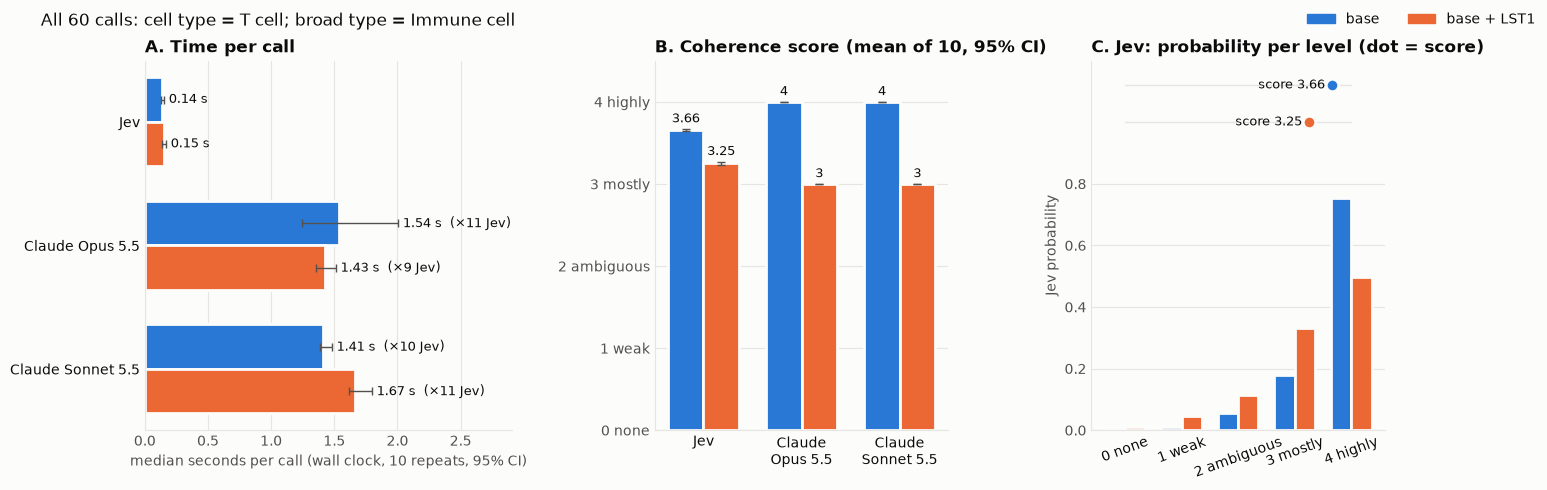

In [9]:
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
CASE_COLOR = dict(zip(cases, ["#2a78d6", "#eb6834"]))       # validated categorical pair
MODELS = ["Jev", *CLAUDE_MODELS]
LEVELS = ["0 none", "1 weak", "2 ambiguous", "3 mostly", "4 highly"]   # short forms of the rubric
W = 0.36                                                     # bar thickness (of a 1.0 slot)
off = dict(zip(cases, [-W / 2, W / 2]))


def style(ax, grid_axis):
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, length=0)


def fmt_level(v):
    return f"{v:.0f}" if float(v).is_integer() else f"{v:.2f}"


ok = calls[calls["status"] == "ok"]
fig, (ax_t, ax_c, ax_p) = plt.subplots(1, 3, figsize=(16, 4.8), facecolor=SURFACE,
                                       gridspec_kw={"width_ratios": [1.25, 1, 1], "wspace": 0.45})

# A. time per call: median bar, 95% CI error bar, label past the error bar
style(ax_t, "x")
for case in cases:
    for i, model in enumerate(MODELS):
        r = summary.loc[(case, model)]
        y = i + off[case]
        ax_t.barh(y, r["median_s"], height=W, color=CASE_COLOR[case], edgecolor=SURFACE, linewidth=2)
        ax_t.errorbar(r["median_s"], y, xerr=[[r["median_s"] - r["median_s_lo"]], [r["median_s_hi"] - r["median_s"]]],
                      fmt="none", ecolor=INK2, elinewidth=1, capsize=3)
        label = f"{r['median_s']:.2f} s" + ("" if model == "Jev" else f"  (\u00d7{r['x_vs_jev']:.0f} Jev)")
        ax_t.text(r["median_s_hi"] + 0.04, y, label, va="center", fontsize=9, color=INK)
ax_t.set_yticks(range(len(MODELS)), MODELS, color=INK)
ax_t.invert_yaxis()
ax_t.set_xlim(0, summary["median_s_hi"].max() * 1.45)
ax_t.set_xlabel(f"median seconds per call (wall clock, {N_REPEATS} repeats, 95% CI)", color=INK2)
ax_t.set_title("A. Time per call", loc="left", color=INK, fontweight="bold")

# B. coherence: mean bar, 95% CI error bar, value above the error bar
style(ax_c, "y")
for case in cases:
    for i, model in enumerate(MODELS):
        r = summary.loc[(case, model)]
        x = i + off[case]
        ax_c.bar(x, r["coherence"], width=W, color=CASE_COLOR[case], edgecolor=SURFACE, linewidth=2)
        ax_c.errorbar(x, r["coherence"], yerr=[[r["coherence"] - r["coherence_lo"]], [r["coherence_hi"] - r["coherence"]]],
                      fmt="none", ecolor=INK2, elinewidth=1, capsize=3)
        ax_c.text(x, r["coherence_hi"] + 0.08, fmt_level(r["coherence"]), ha="center", fontsize=9, color=INK)
ax_c.set_xticks(range(len(MODELS)), [m.replace("Claude ", "Claude\n") for m in MODELS], color=INK)
ax_c.set_ylim(0, 4.5)
ax_c.set_yticks(range(5), LEVELS)
ax_c.set_title(f"B. Coherence score (mean of {N_REPEATS}, 95% CI)", loc="left", color=INK, fontweight="bold")

# C. Jev's probability per coherence level, and the score it implies
style(ax_p, "y")
jev = [r for r in raw if r["model"] == "Jev" and r["response"]]
for case in cases:
    probs = pd.DataFrame([r["response"]["answers"]["identity_coherence"]["probabilities"]
                          for r in jev if r["case"] == case]).astype(float).mean()
    xs = probs.index.astype(int)
    ax_p.bar(xs + off[case], probs.values, width=W, color=CASE_COLOR[case], edgecolor=SURFACE, linewidth=2)
    score = ok[(ok["case"] == case) & (ok["model"] == "Jev")]["coherence"].mean()
    track = 1.12 if case == "base" else 1.0
    ax_p.plot([0, 4], [track, track], color=GRID, linewidth=1, zorder=1)
    ax_p.scatter([score], [track], s=80, color=CASE_COLOR[case], edgecolors=SURFACE, linewidths=2, zorder=3)
    ax_p.text(score - 0.12, track, f"score {score:.2f}", ha="right", va="center", fontsize=9, color=INK)
ax_p.set_xticks(range(5), LEVELS, rotation=20, color=INK)
ax_p.set_ylim(0, 1.2)
ax_p.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax_p.set_ylabel("Jev probability", color=INK2)
ax_p.set_title("C. Jev: probability per level (dot = score)", loc="left", color=INK, fontweight="bold")

# One legend for the figure; the headline answers go in the title
handles = [plt.Rectangle((0, 0), 1, 1, color=CASE_COLOR[c]) for c in cases]
fig.legend(handles, list(cases), loc="upper right", ncol=2, frameon=False, labelcolor=INK)
answers = {f"{q.replace('_', ' ')} = {', '.join(sorted(ok[q].unique()))}" for q in ("cell_type", "broad_type")}
fig.suptitle(f"All {len(ok)} calls: " + "; ".join(sorted(answers, reverse=True)),
             x=0.06, ha="left", color=INK, fontsize=12)
plt.show()

## Worked example: how Jev's coherence score is computed

Jev returns one probability per rubric level. The score is the sum of each level times its probability. The numbers below come from the first `base` call in this run.

In [10]:
ex = next(r for r in raw if r["model"] == "Jev" and r["case"] == "base" and r["response"])
coh = ex["response"]["answers"]["identity_coherence"]
terms = " + ".join(f"{lvl}\u00d7{p:.2f}" for lvl, p in coh["probabilities"].items())
by_hand = sum(int(lvl) * p for lvl, p in coh["probabilities"].items())
print(f"{terms} = {by_hand:.2f}")
print(f"Jev reported {coh['score']}; any small gap is because the probabilities are rounded to 2 decimals.")

0×0.00 + 1×0.01 + 2×0.06 + 3×0.17 + 4×0.76 = 3.68
Jev reported 3.65; any small gap is because the probabilities are rounded to 2 decimals.


## Save

Writes four files, stamped with the run time, to `outputs/`:
- every call;
- the summary;
- the raw responses;
- the figure.

Raw responses contain no credentials.

In [11]:
OUTPUTS.mkdir(exist_ok=True)
stamp = time.strftime("%Y%m%d-%H%M%S")
calls.to_csv(OUTPUTS / f"calls_{stamp}.csv", index=False)
summary.to_csv(OUTPUTS / f"summary_{stamp}.csv")
(OUTPUTS / f"raw_{stamp}.json").write_text(json.dumps(raw, indent=2, default=str))
fig.savefig(OUTPUTS / f"figure_{stamp}.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
print("saved", sorted(p.name for p in OUTPUTS.glob(f"*_{stamp}.*")))

saved ['calls_20261005-152936.csv', 'figure_20261005-152936.png', 'raw_20261005-152936.json', 'summary_20261005-152936.csv']


## Conclusion (from this run)

- **Same answers.** All three models called both lists T cell / Immune cell in every call. Adding LST1 changed no label.
- **All three noticed LST1.** Coherence fell from 4 to 3 for both Claude models and from 3.66 to 3.25 for Jev.
- **Jev was about 10× faster**: 0.14 s per call vs about 1.5 s for Claude.

This is one easy cluster. Accuracy needs many clusters with known labels.